# Stochastic evolution of a colony of B cells

Eval of impact of mutation rate on the evolution of a colony of B cells.

In [1]:
import matplotlib.pyplot as plt
from __future__ import annotations
import numpy as np
from numpy.random import default_rng
import pandas as pd
from collections import defaultdict
import matplotlib.ticker as mtick


In [7]:
"""
Germinal‑centre B‑cell maturation with multiple antigens
========================================================

• State of each cycling B‑cell: h ∈ ℝ^{N_h} (residue binding‑energy vector)
• Antigens:            S_mat ∈ {‑1, +1}^{N_h × n_A}
                       ε_v(h) = Σ_i s_{iv} h_i    for every antigen v
• One round:           duplication → SHM → Ag‑gate → T‑gate → differentiation
• Output:              `history[step]` is a NumPy array of shape
                       (n_cells_alive_that_step, N_h) with the h‑vectors

The implementation below follows exactly the gates used in your FP solver.
"""




E_a=np.log(40)                       
T=140
T_steps = 140

kBT=1                       # thermal factor
N_i=2500  
N_max=2500 
mu_i=0.0 
sigma_i=0.001 

p_diff=0.10
c=170# 800, 1120, 920, 510

# global parameters (use existing values or define defaults)

# -------------------------- helper functions ---------------------------
def energies(pop: np.ndarray, S_mat: np.ndarray) -> np.ndarray:
    """
    Compute energies for every cell and every antigen.

    Parameters
    ----------
    pop   : (N_cells, N_h) ndarray
    S_mat : (N_h, n_A)     ndarray

    Returns
    -------
    eps : (N_cells, n_A) ndarray   with eps[c, v] = ε_v(h_c)
    """
    return pop @ S_mat                     # broadcasting handles dot‑product

def P_Ag(eps: np.ndarray, C_vec: np.ndarray) -> np.ndarray:
    """
    Antigen‑binding survival gate   P_Ag(h)

    eps   : (N_cells, n_A) energies
    C_vec : (n_A,)        antigen concentrations at current round
    """
    exp_term   = np.exp((eps - E_a) / kBT)         # same as FP code
    numer      = (exp_term * C_vec).sum(axis=1)    # Σ_v C_v e^{(ε_v - E_a)/kT}
    return numer / (1.0 + numer)

def P_T(eps: np.ndarray, C_vec: np.ndarray) -> np.ndarray:
    """
    T‑cell‑help survival gate   P_T(h | pop)

    eps   : (N_cells, n_A) energies *after* Ag selection
    """
    C_tot      = C_vec.sum()
    eE         = np.exp(eps / kBT)                 # e^{ε_v/kT}
    Phi        = (eE * C_vec).sum(axis=1)          # Σ_v C_v e^{ε_v/kT}
    Phi_bar    = Phi.mean()                       # ⟨Φ⟩_pop
    return Phi / (Phi + Phi_bar / C_tot)

# --

## Trying to track mutations

In [4]:
def gc_round(pop: np.ndarray,
             S_mat: np.ndarray,
             C_vec: np.ndarray,
             rng: np.random.Generator,
             mu_M: np.ndarray,
             sigma_M: np.ndarray,
             mutable_positions=None,
             uniq_counts: np.ndarray | None = None,        # NEW: unique mutated sites per cell
             mut_sites: np.ndarray | None = None ,          # NEW: boolean mask (n_cells, N_h)
             mu_aa=0.001
             ) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Returns:
        pop_next   : GC survivors after differentiation (n_t, N_h)
        mem_cells  : differentiated cells (n_mem, N_h)
        parent_idx : parent row index in previous gen (n_t,)
        uniq_counts: unique mutated-site counts aligned to pop_next (n_t,)
        mut_sites  : boolean mutated-sites mask aligned to pop_next (n_t, N_h)
    Counting rule: only the first mutation at a site counts for that lineage; repeated hits to the same site do not.
    """
    N_h = pop.shape[1]
    assert mu_M.shape == (N_h,) and sigma_M.shape == (N_h,), "mu_M and sigma_M must be length N_h"

    # init counters/masks for gen-0
    if uniq_counts is None:
        uniq_counts = np.zeros(pop.shape[0], dtype=int)
    if mut_sites is None:
        mut_sites = np.zeros((pop.shape[0], N_h), dtype=bool)

    # 1) Duplication: replicate state, counts, and masks; track parents
    prev_n = pop.shape[0]
    pop        = np.repeat(pop,        2, axis=0)
    uniq_counts = np.repeat(uniq_counts, 2, axis=0)
    mut_sites  = np.repeat(mut_sites,  2, axis=0)
    parent_idx = np.repeat(np.arange(prev_n, dtype=int), 2)


    # 2) SHM: at most one site per mutating cell this round

    mu=mu_aa*3*40
    p_sil=0.5*(mu)+(1-mu)
    p_let=0.3*(mu)
    p_aa=0.2*(mu)

    N_cells = pop.shape[0]
    fate = rng.choice(["let", "aa", "sil"], size=N_cells, p=[p_let, p_aa, p_sil])
    alive_mask = fate != "let"
    aa_mask    = fate == "aa"

    if aa_mask.any():
        rows = np.flatnonzero(aa_mask)
        if mutable_positions is None:
            idx_sites = rng.integers(0, N_h, size=rows.size)
        else:
            mp = np.asarray(mutable_positions, dtype=int)
            idx_sites = rng.choice(mp, size=rows.size)
        delta_h = rng.normal(mu_M[idx_sites], sigma_M[idx_sites])
        # apply mutation to h
        # pop[rows, idx_sites] = np.clip(pop[rows, idx_sites] + delta_h, -3*np.log(10), 1*np.log(10))
        pop[rows, idx_sites] = pop[rows, idx_sites] + delta_h
        # UNIQUE-SITE counting: only first hit to a site increments
        # (relative to this lineage's gen-0 founder; we encode that by the boolean mut_sites)
        for r, i in zip(rows, idx_sites):
            if not mut_sites[r, i]:
                uniq_counts[r] += 1
                mut_sites[r, i] = True

    # lethal removal
    pop        = pop[alive_mask]
    parent_idx = parent_idx[alive_mask]
    uniq_counts = uniq_counts[alive_mask]
    mut_sites  = mut_sites[alive_mask]
    if pop.size == 0:
        return pop, np.empty((0, N_h)), np.empty((0,), dtype=int), np.empty((0,), dtype=int), np.empty((0, N_h), dtype=bool)

    # 3) Antigen-binding gate (shape-safe reduction over possible multi-C_vec outputs)
    eps  = energies(pop, S_mat)
    P_ag = P_Ag(eps, C_vec)
    if isinstance(P_ag, np.ndarray) and P_ag.ndim == 2:
        P_ag = P_ag.max(axis=1)  # or .mean/.min per your policy
    P_ag = np.asarray(P_ag, dtype=float).reshape(-1)
    assert P_ag.shape[0] == pop.shape[0]
    survive = rng.random(pop.shape[0]) < P_ag

    pop        = pop[survive]
    parent_idx = parent_idx[survive]
    uniq_counts = uniq_counts[survive]
    mut_sites  = mut_sites[survive]
    if pop.size == 0:
        return pop, np.empty((0, N_h)), np.empty((0,), dtype=int), np.empty((0,), dtype=int), np.empty((0, N_h), dtype=bool)

    # 4) T-cell-help gate (shape-safe)
    P_t = P_T(eps, C_vec)
    if isinstance(P_t, np.ndarray) and P_t.shape[0] != pop.shape[0]:
        eps_t = energies(pop, S_mat)
        P_t = P_T(eps_t, C_vec)
    if isinstance(P_t, np.ndarray) and P_t.ndim == 2:
        P_t = P_t.max(axis=1)
    P_t = np.asarray(P_t, dtype=float).reshape(-1)
    if P_t.shape[0] != pop.shape[0]:
        if P_t.size == 1:
            P_t = np.full(pop.shape[0], float(P_t))
        else:
            raise ValueError(f"P_T shape {P_t.shape} must match n_cells {pop.shape[0]}")
    survive = rng.random(pop.shape[0]) < P_t

    pop        = pop[survive]
    parent_idx = parent_idx[survive]
    uniq_counts = uniq_counts[survive]
    mut_sites  = mut_sites[survive]
    if pop.size == 0:
        return pop, np.empty((0, N_h)), np.empty((0,), dtype=int), np.empty((0,), dtype=int), np.empty((0, N_h), dtype=bool)

    # 5) Differentiation
    diff_mask  = rng.random(size=pop.shape[0]) < p_diff
    mem_cells  = pop[diff_mask]
    keep_mask  = ~diff_mask
    pop        = pop[keep_mask]
    parent_idx = parent_idx[keep_mask]
    uniq_counts = uniq_counts[keep_mask]
    mut_sites  = mut_sites[keep_mask]

    return pop, mem_cells, parent_idx, uniq_counts, mut_sites


In [5]:
def plot_h_dimension(history, dim_idx=0, h_min=-4, h_max=10, n_hbins=100, t_clip=50, cmap="Greys_r"):
    """
    Plot the density of B-cell h[dim_idx] values over rounds with fixed colorbar scale [0, 500].
    """
    time_points = []
    h_values = []
    for t, pop in enumerate(history):
        if pop.size == 0:
            continue
        time_points.extend([t] * pop.shape[0])
        h_values.extend(pop[:, dim_idx])

    rounds_arr = np.asarray(time_points)
    h_vals     = np.asarray(h_values)

    n_rounds   = len(history)
    round_bins = np.linspace(rounds_arr.min(), rounds_arr.max(), n_rounds + 1)
    h_bins     = np.linspace(h_min, h_max, n_hbins + 1)

    H, xedges, yedges = np.histogram2d(rounds_arr, h_vals, bins=[round_bins, h_bins])

    plt.figure(figsize=(8, 5))
    im = plt.imshow(H.T, origin="lower", aspect="auto",
                    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                     vmin=0.0, vmax=100)  # fixed scale
    plt.xlabel("Round")
    plt.ylabel(rf"$h_{{{dim_idx+1}}}$")
    plt.title(rf"Density of B-cells in $h_{{{dim_idx+1}}}$ over GC rounds")
    plt.colorbar(im, label="Density")
    plt.ylim(h_min, h_max)
    plt.tight_layout()
    plt.show()

In [8]:
import numpy as np
from numpy.random import default_rng

def simulate_gc_with_ancestry(rounds: int,
                              S_mat: np.ndarray,
                              N_init: int,
                              N_max: int,
                              C_schedule,
                              mu_init: float = mu_i,   # Update with your default mu_i if needed
                              sigma_init: float = sigma_i, # Update with your default sigma_i if needed
                              mu_M: np.ndarray | None = None,
                              sigma_M: np.ndarray | None = None,
                              mutable_positions=None,
                              seed: int | None = None,
                              mu_aa=0.001
                              ) -> list[dict]:
    """
    Simulates GC evolution and tracks ancestry using global unique IDs.
    
    Returns:
        history : list of dicts per generation (t=0..T). Keys:
                  'ids': global unique cell IDs
                  'parent_ids': global IDs of the parents (-1 for root)
                  'pop': cell states (N, N_h)
                  'uniq_counts': unique mutated-site count aligned to pop
    """
    rng = default_rng(seed)
    N_h = S_mat.shape[0]
    if mu_M is None or sigma_M is None:
        raise ValueError("Provide per-site mu_M and sigma_M of shape (N_h,)")

    pop = rng.normal(mu_init, sigma_init, size=(N_init, N_h))
    if mutable_positions is not None:
        mutable_positions = np.array(mutable_positions, dtype=int)
        all_positions = np.arange(N_h)
        non_mutable_positions = np.setdiff1d(all_positions, mutable_positions)
        pop[:, non_mutable_positions] = 0.0

    # Initialize ID tracking
    next_id = N_init
    initial_ids = np.arange(N_init, dtype=int)
    initial_parent_ids = np.full(N_init, -1, dtype=int)

    # Setup history as list of dicts
    uniq_counts = np.zeros(pop.shape[0], dtype=int)
    mut_sites = np.zeros((pop.shape[0], N_h), dtype=bool)

    history = [{
        'ids': initial_ids,
        'parent_ids': initial_parent_ids,
        'pop': pop.copy(),
        'uniq_counts': uniq_counts.copy()
    }]

    for r in range(rounds):
        C_vec = np.asarray(C_schedule(r), dtype=float)
        
        # Run GC round
        pop_next, _mem, parent_idx, uniq_counts, mut_sites = gc_round(
            pop, S_mat, C_vec, rng, mu_M, sigma_M,
            mutable_positions=mutable_positions,
            uniq_counts=uniq_counts, mut_sites=mut_sites,
            mu_aa=mu_aa
        )

        # Apply capacity cap consistently
        if pop_next.shape[0] > N_max:
            keep_idx   = rng.choice(pop_next.shape[0], N_max, replace=False)
            pop_next   = pop_next[keep_idx]
            parent_idx = parent_idx[keep_idx]
            uniq_counts = uniq_counts[keep_idx]
            mut_sites   = mut_sites[keep_idx]

        # Map row indices to actual global parent IDs from the previous frame
        prev_ids = history[-1]['ids']
        current_parent_ids = prev_ids[parent_idx]

        # Assign new global IDs to the survivors
        n_survivors = pop_next.shape[0]
        current_ids = np.arange(next_id, next_id + n_survivors, dtype=int)
        next_id += n_survivors

        # Store generation data
        history.append({
            'ids': current_ids,
            'parent_ids': current_parent_ids,
            'pop': pop_next.copy(),
            'uniq_counts': uniq_counts.copy()
        })
        
        pop = pop_next

    return history

In [9]:
df = pd.read_csv('../data_mat/final_variant_scores.csv')

# Use the .isin() method for filtering rows based on a list of values
allowed_annotations = ['CDRH1', 'CDRH2', 'CDRH3', 'CDRL1', 'CDRL2', 'CDRL3']
df = df[df['annotation'].isin(allowed_annotations)]
df['annotation'].unique()

print(df["delta_bind_CGG"].mean() * np.log(10))

print(df["delta_bind_CGG"].std()* np.log(10))


-1.031567993994919
1.7515742333362647


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Group by position, take the first wildtype amino acid for each position
wt_seq = (
    df.groupby("position")["wildtype"]
      .first()
      .sort_index()
      .str.cat()
)
print('len',len(wt_seq))

print(wt_seq)

df = df[df["single_nt"].apply(lambda x: isinstance(x, bool))]
df = df[df["single_nt"]]  # keep only single-nt rows
df['position'] = df['position'] - 1

print(df["delta_bind_CGG"].mean() * np.log(10))

print(df["delta_bind_CGG"].std()* np.log(10))

# Group and compute mean/std
stats = df.groupby(["position", "annotation"])["delta_bind_CGG"].agg(["mean", "std"]).reset_index()

# Arrays (ordered by position)
positions = stats["position"].to_numpy()
mu_arr = stats["mean"].to_numpy() * np.log(10)
sigma_arr = stats["std"].to_numpy() * np.log(10)

print(len(positions))
print(mu_arr)
print(sigma_arr)
print(mu_arr.mean())





len 40
GDSITSGYYISYSGSTARDFDVQNVGTNSASQQYNSYPLT
-0.7913685301950631
1.6864998765917716
40
[ 0.22103172  1.26389759  0.16960184 -0.71205141 -0.30731452 -0.0529463
 -1.51018662 -3.14495296 -1.98401587  0.09835657 -0.52276576 -0.26164932
 -0.73205759 -0.26663277  0.19565394  0.25604362 -1.31664118 -3.35076788
 -2.18586993 -0.46051044 -1.0071536  -0.33069069  0.2339887   0.06324913
 -0.7381397  -0.74947829 -0.41773883 -1.21797829 -1.58449323 -0.40320568
 -0.49252295 -0.98764125 -1.55631726 -3.4382398   0.94925222  0.30822404
 -3.07005644 -1.47618401 -0.7327681  -0.6213164 ]
[0.5331775  0.74049486 0.19864102 0.91713086 0.78067121 0.1466031
 1.1957676  2.79081499 1.91297848 0.22728794 0.72413258 0.71696882
 2.14744907 0.44998865 0.84405372 0.20062656 2.00137303 2.26438893
 1.67674228 0.92123678 1.2942475  0.58379482 0.61148675 0.201573
 1.30095802 0.89456854 0.57941635 1.73745639 2.42484008 1.23658201
 1.31855134 1.95551488 1.42024837 2.30692581 1.14894814 0.70163801
 2.07314568 0.91044491 2

In [11]:
print(df.annotation.unique())
# Keep only unique (position, annotation) pairs
pos_annotation_dict = (
    df.drop_duplicates(subset=["position", "annotation"])
      .set_index("position")["annotation"]
      .to_dict()
)

print(pos_annotation_dict)
cdr_positions = (
    df[df["annotation"].str.contains("CDR", na=False)]
    .drop_duplicates(subset=["position"])
    [["position"]]
    .to_records(index=False)
    .tolist()
)
cdr_positions=[pos[0] for pos in cdr_positions]
print(cdr_positions)#absolute position
#i need index of cdr_positions inside position array
cdr_positions_relative = [np.where(positions == p)[0][0] for p in cdr_positions]

print(cdr_positions_relative)

['CDRH1' 'CDRH2' 'CDRH3' 'CDRL1' 'CDRL2' 'CDRL3']
{25: 'CDRH1', 26: 'CDRH1', 27: 'CDRH1', 28: 'CDRH1', 29: 'CDRH1', 30: 'CDRH1', 31: 'CDRH1', 32: 'CDRH1', 49: 'CDRH2', 50: 'CDRH2', 51: 'CDRH2', 52: 'CDRH2', 53: 'CDRH2', 54: 'CDRH2', 55: 'CDRH2', 56: 'CDRH2', 95: 'CDRH3', 96: 'CDRH3', 97: 'CDRH3', 98: 'CDRH3', 99: 'CDRH3', 100: 'CDRH3', 153: 'CDRL1', 154: 'CDRL1', 155: 'CDRL1', 156: 'CDRL1', 157: 'CDRL1', 158: 'CDRL1', 176: 'CDRL2', 177: 'CDRL2', 178: 'CDRL2', 215: 'CDRL3', 216: 'CDRL3', 217: 'CDRL3', 218: 'CDRL3', 219: 'CDRL3', 220: 'CDRL3', 221: 'CDRL3', 222: 'CDRL3', 223: 'CDRL3'}
[25, 26, 27, 28, 29, 30, 31, 32, 49, 50, 51, 52, 53, 54, 55, 56, 95, 96, 97, 98, 99, 100, 153, 154, 155, 156, 157, 158, 176, 177, 178, 215, 216, 217, 218, 219, 220, 221, 222, 223]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load and Process Experimental Data (from original code, unchanged) ---
# NOTE: Assume 'simulate_gc_history', T, S_mat, N_i, N_max, C_schedule, mu_arr,
# sigma_arr, and cdr_positions_relative are defined elsewhere in the context.
S_mat = np.array([[1] for pos in range (len(positions))])

N_h   = S_mat.shape[0]
print('Nh', N_h)
# Antigen concentration (constant here)
c=170
def C_schedule(r):
    return np.array([c])

Nh 40


<>:60: SyntaxWarning: invalid escape sequence '\m'
<>:63: SyntaxWarning: invalid escape sequence '\l'
<>:60: SyntaxWarning: invalid escape sequence '\m'
<>:63: SyntaxWarning: invalid escape sequence '\l'
C:\Users\maria\AppData\Local\Temp\ipykernel_8620\579388374.py:60: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(times, mean_affinity, label=f"$\mu_{{aa}}$ = {mu_aa}", linewidth=2)
C:\Users\maria\AppData\Local\Temp\ipykernel_8620\579388374.py:63: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("Average Population Affinity $\langle \sum h_i \\rangle$")



Running simulations for mu_aa = 0.0005
  Seed 1/10 done.
  Seed 2/10 done.
  Seed 3/10 done.
  Seed 4/10 done.
  Seed 5/10 done.
  Seed 6/10 done.
  Seed 7/10 done.
  Seed 8/10 done.
  Seed 9/10 done.
  Seed 10/10 done.

Running simulations for mu_aa = 0.001
  Seed 1/10 done.
  Seed 2/10 done.
  Seed 3/10 done.
  Seed 4/10 done.
  Seed 5/10 done.
  Seed 6/10 done.
  Seed 7/10 done.
  Seed 8/10 done.
  Seed 9/10 done.
  Seed 10/10 done.

Running simulations for mu_aa = 0.002
  Seed 1/10 done.
  Seed 2/10 done.
  Seed 3/10 done.
  Seed 4/10 done.
  Seed 5/10 done.
  Seed 6/10 done.
  Seed 7/10 done.
  Seed 8/10 done.
  Seed 9/10 done.
  Seed 10/10 done.


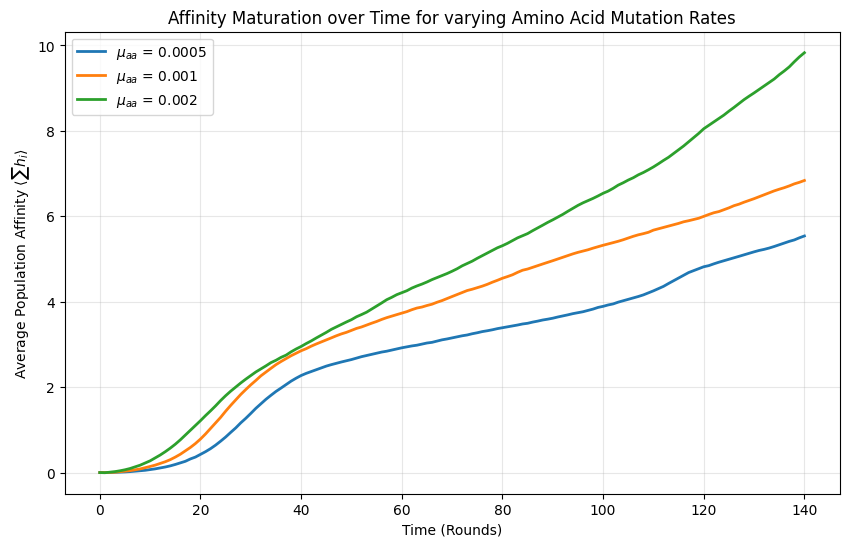

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Simulation Parameters ---
# (Assumes T, S_mat, N_i, N_max, C_schedule, mu_arr, sigma_arr, 
# cdr_positions_relative are already defined in your environment)
N_SEEDS = 10 
mu_aa_array = np.array([0.0005, 0.001, 0.002])

# Dictionary to store the aggregated results for each mu_aa
results_per_mu = {}

# --- 2. Run Simulations ---
for mu_aa in mu_aa_array:
    print(f"\nRunning simulations for mu_aa = {mu_aa}")
    all_seeds_mean_sum_hi = [] 

    for seed in range(N_SEEDS):
        # Run simulation - Ensure mu_aa is passed correctly to your function
        history = simulate_gc_with_ancestry(
            rounds            = T,
            S_mat             = S_mat,
            N_init            = N_i,
            N_max             = N_max,
            C_schedule        = C_schedule,
            mu_M              = mu_arr,
            sigma_M           = sigma_arr,
            mutable_positions = cdr_positions_relative,
            seed              = seed + 1, 
            mu_aa             = mu_aa  # Use the loop variable here
        )

        current_seed_time_course = []

        for frame in history:
            pop = frame['pop']
            
            if pop.size == 0:
                current_seed_time_course.append(np.nan)
            else:
                # Treat unmutated positions (NaNs) as 0.0 affinity contribution
                pop_filled = np.nan_to_num(pop, nan=0.0)
                # Calculate total affinity per cell, then average over population
                avg_pop_affinity = pop_filled.sum(axis=1).mean()
                current_seed_time_course.append(avg_pop_affinity)

        all_seeds_mean_sum_hi.append(current_seed_time_course)
        print(f"  Seed {seed + 1}/{N_SEEDS} done.")

    # Convert to array (Seeds, Time) and calculate mean across seeds
    all_seeds_mean_sum_hi = np.array(all_seeds_mean_sum_hi)
    results_per_mu[mu_aa] = np.nanmean(all_seeds_mean_sum_hi, axis=0)

# --- 3. Plotting ---
plt.figure(figsize=(10, 6))
times = np.arange(T + 1)

for mu_aa, mean_affinity in results_per_mu.items():
    plt.plot(times, mean_affinity, label=f"$\mu_{{aa}}$ = {mu_aa}", linewidth=2)

plt.xlabel("Time (Rounds)")
plt.ylabel("Average Population Affinity $\langle \sum h_i \\rangle$")
plt.title("Affinity Maturation over Time for varying Amino Acid Mutation Rates")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

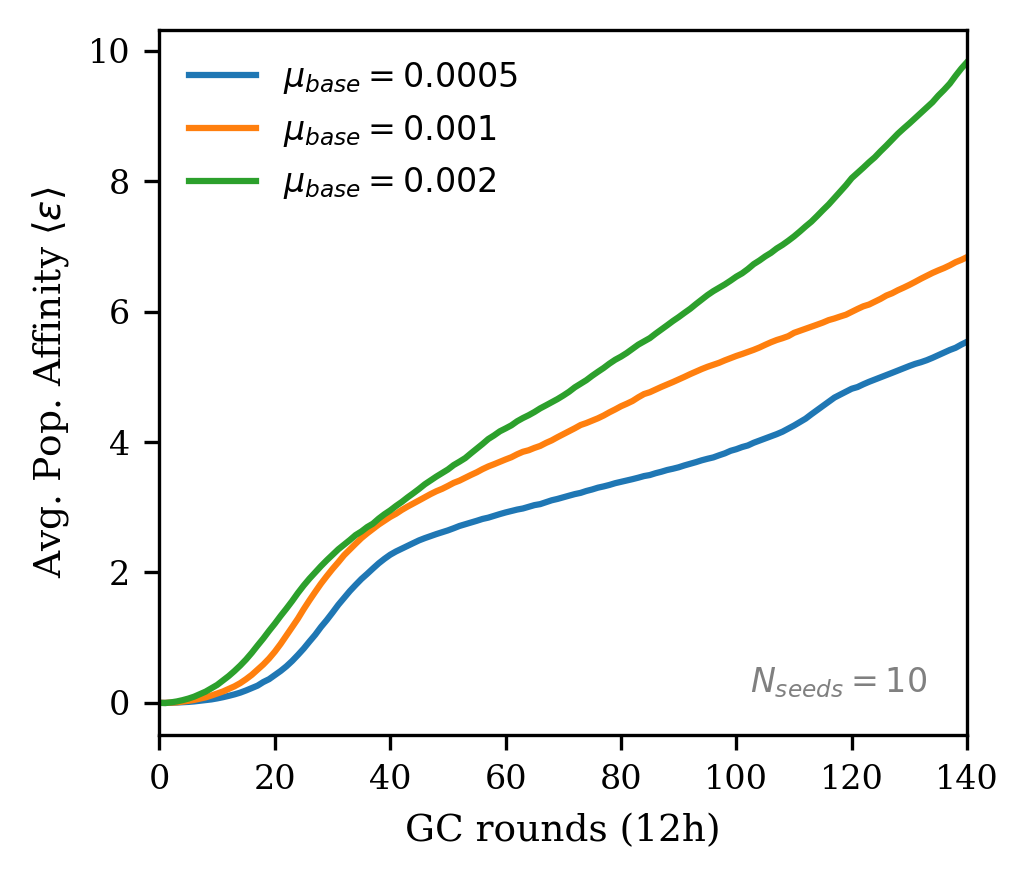

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# --- Publication Quality Formatting ------------------------------------
plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.markersize": 4,
    "figure.figsize": (3.5, 3.0),  # Slightly wider for legend
    "figure.dpi": 300,
    "font.family": "serif",
    "text.usetex": False           # Set to True if you have a LaTeX distribution
})

fig, ax = plt.subplots()

# Colors for different mutation rates
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
times = np.arange(T + 1)

# --- Plotting loop -----------------------------------------------------
for i, (mu_aa, mean_affinity) in enumerate(results_per_mu.items()):
    # If you saved the full simulation array (Seeds, Time) in a dict:
    # (Assuming you named the raw data dictionary 'raw_results_per_mu')
    # data = raw_results_per_mu[mu_aa]
    # mean_h = np.nanmean(data, axis=0)
    # std_h  = np.nanstd(data, axis=0)
    
    # Using the aggregated mean from your results_per_mu
    label_str = r"$\mu_{base} = " + f"{mu_aa}" + "$"
    ax.plot(times, mean_affinity, lw=1.5, color=colors[i % len(colors)], label=label_str)
    
    # Optional: Add shaded error if standard deviation is available
    # ax.fill_between(times, mean_h - std_h, mean_h + std_h, 
    #                 color=colors[i % len(colors)], alpha=0.2)

# --- Final formatting -------------------------------------------------
ax.set_xlim(0, T)
ax.set_xlabel("GC rounds (12h)")
ax.set_ylabel(r"Avg. Pop. Affinity $\langle \epsilon \rangle$")

# Clean legend without frame
ax.legend(frameon=False, loc="upper left", fontsize=8)

# Add target or parameter info text
ax.text(0.95, 0.05, r"$N_{seeds} = 10$", transform=ax.transAxes, 
        ha='right', va='bottom', fontsize=8, color='grey')

fig.tight_layout()
plt.show()